# Visualisation de l'impact de l'initialisation

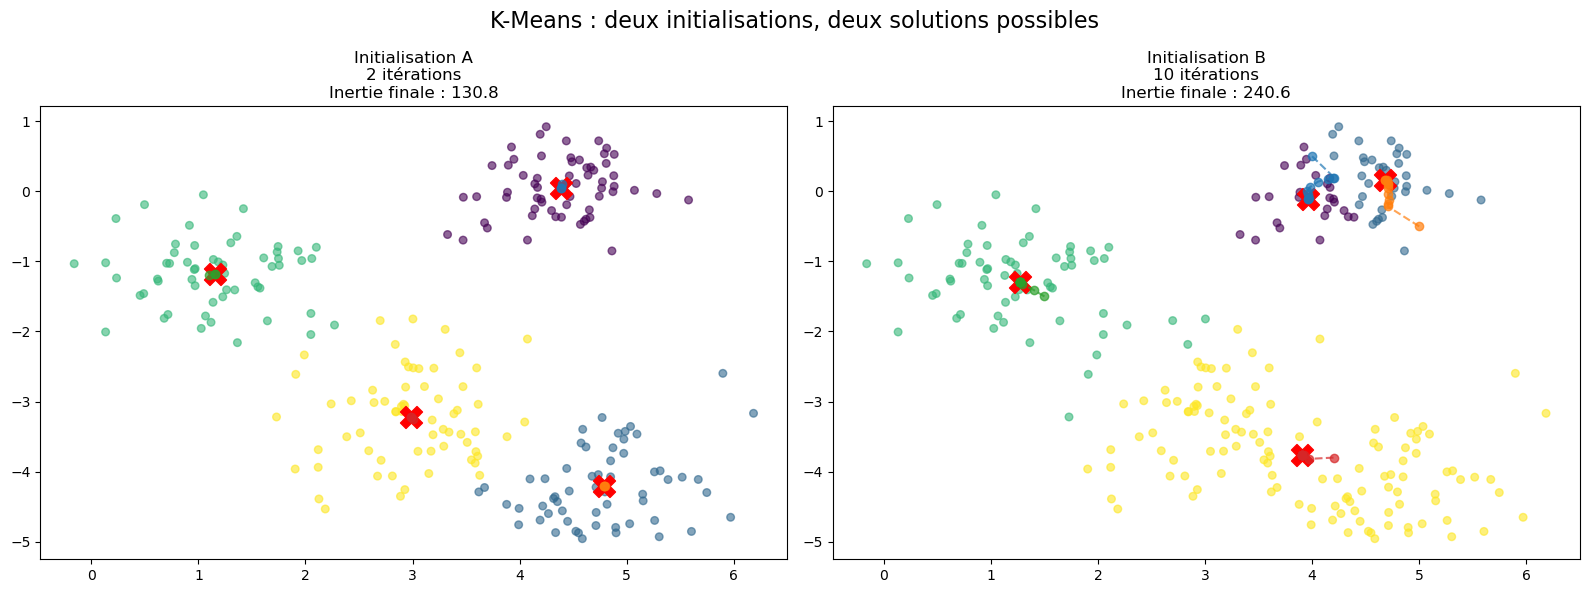

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Création du dataset
# ---------------------------------------------------------

rng = np.random.default_rng(42)

# Quatre groupes volontairement proches et déséquilibrés
group_1 = rng.normal(
    loc=[4.4, 0.1],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_2 = rng.normal(
    loc=[4.8, -4.2],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_3 = rng.normal(
    loc=[1.1, -1.2],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_4 = rng.normal(
    loc=[3.0, -3.25],
    scale=[0.55, 0.55],
    size=(60, 2)
)

X = np.vstack([
    group_1,
    group_2,
    group_3,
    group_4
])


# ---------------------------------------------------------
# 2. Implémentation simplifiée de K-Means
# ---------------------------------------------------------

def run_kmeans_with_history(X, initial_centers, max_iter=20):
    """Exécute K-Means et conserve les centroïdes à chaque itération."""

    centers = initial_centers.copy()
    history = [centers.copy()]

    for _ in range(max_iter):

        # Affectation des observations
        distances = np.linalg.norm(
            X[:, np.newaxis] - centers,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        # Recalcul des centroïdes
        new_centers = np.array([
            X[labels == cluster_id].mean(axis=0)
            for cluster_id in range(len(centers))
        ])

        history.append(new_centers.copy())

        # Convergence
        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return labels, history


# ---------------------------------------------------------
# 3. Deux initialisations différentes
# ---------------------------------------------------------

# Initialisation qui permet de retrouver les quatre groupes
good_init = np.array([
    [4.4, 0.1],
    [4.8, -4.2],
    [1.1, -1.2],
    [3.0, -3.25]
])


# Initialisation volontairement défavorable :
# deux centroïdes sont placés dans la zone supérieure,
# ce qui peut conduire K-Means vers une autre partition.
bad_init = np.array([
    [4.0, 0.5],
    [5.0, -0.5],
    [1.5, -1.5],
    [4.2, -3.8]
])


# ---------------------------------------------------------
# 4. Exécution
# ---------------------------------------------------------

labels_good, history_good = run_kmeans_with_history(
    X,
    good_init
)

labels_bad, history_bad = run_kmeans_with_history(
    X,
    bad_init
)


# ---------------------------------------------------------
# 5. Calcul de l'inertie
# ---------------------------------------------------------

def calculate_inertia(X, labels, centers):
    """Calcule l'inertie d'une solution."""

    return sum(
        np.sum(
            (X[labels == cluster_id] - centers[cluster_id]) ** 2
        )
        for cluster_id in range(len(centers))
    )


inertia_good = calculate_inertia(
    X,
    labels_good,
    history_good[-1]
)

inertia_bad = calculate_inertia(
    X,
    labels_bad,
    history_bad[-1]
)


# ---------------------------------------------------------
# 6. Visualisation
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ---------------------------------------------------------
# Bonne initialisation
# ---------------------------------------------------------

axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=labels_good,
    cmap='viridis',
    s=30,
    alpha=0.6
)

history = np.array(history_good)

for cluster_id in range(4):
    axes[0].plot(
        history[:, cluster_id, 0],
        history[:, cluster_id, 1],
        marker='o',
        linestyle='--',
        alpha=0.7
    )

centers = history_good[-1]

axes[0].scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    marker='X',
    color='red'
)

axes[0].set_title(
    f'Initialisation A\n'
    f'{len(history_good) - 1} itérations\n'
    f'Inertie finale : {inertia_good:.1f}'
)


# ---------------------------------------------------------
# Mauvaise initialisation
# ---------------------------------------------------------

axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=labels_bad,
    cmap='viridis',
    s=30,
    alpha=0.6
)

history = np.array(history_bad)

for cluster_id in range(4):
    axes[1].plot(
        history[:, cluster_id, 0],
        history[:, cluster_id, 1],
        marker='o',
        linestyle='--',
        alpha=0.7
    )

centers = history_bad[-1]

axes[1].scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    marker='X',
    color='red'
)

axes[1].set_title(
    f'Initialisation B\n'
    f'{len(history_bad) - 1} itérations\n'
    f'Inertie finale : {inertia_bad:.1f}'
)


plt.suptitle(
    "K-Means : deux initialisations, deux solutions possibles",
    fontsize=16
)

plt.tight_layout()
plt.show()

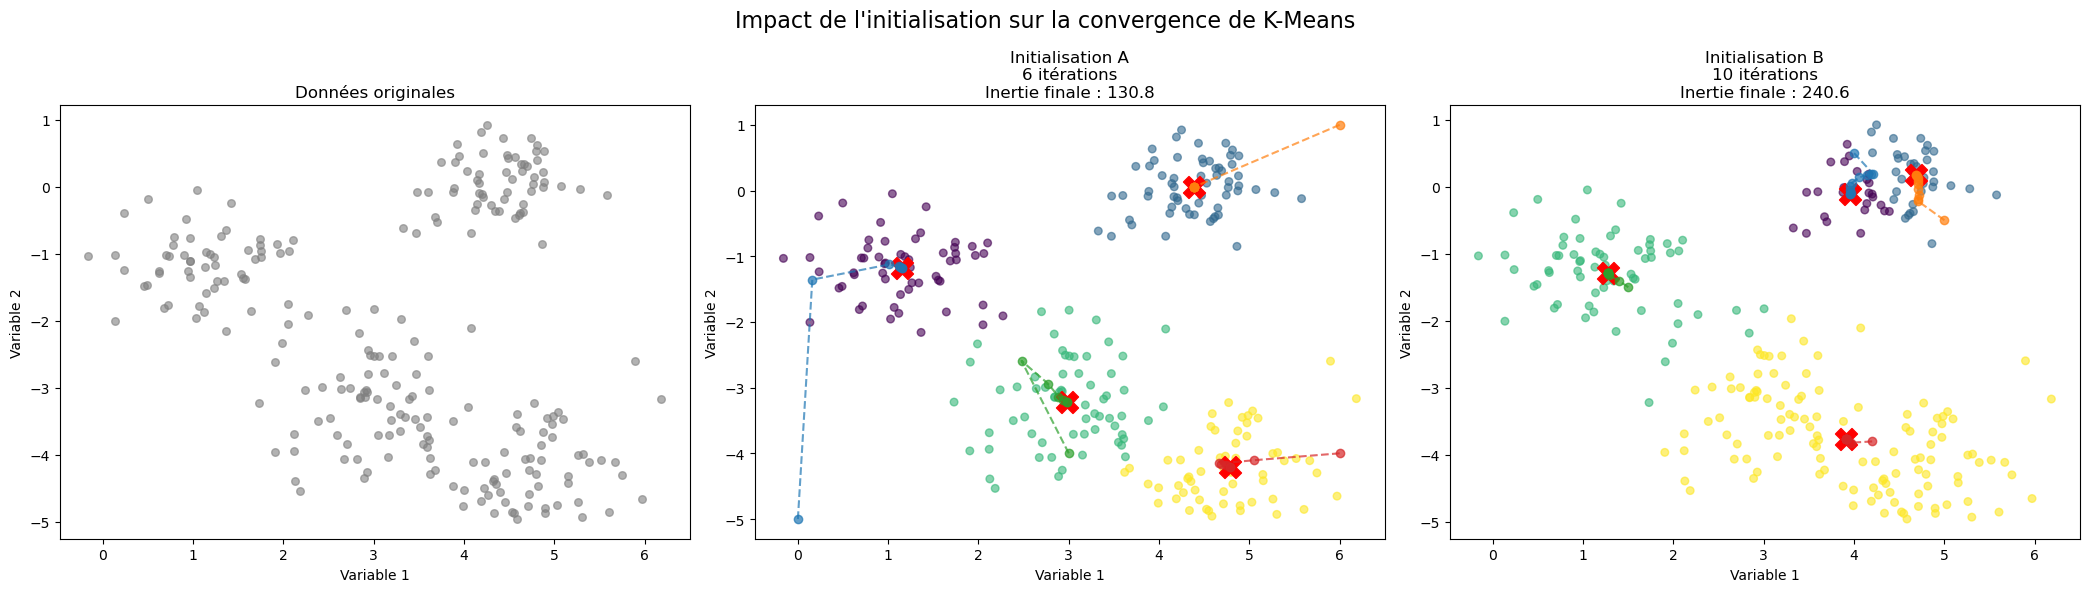

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Création du dataset
# ---------------------------------------------------------

rng = np.random.default_rng(42)

group_1 = rng.normal(
    loc=[4.4, 0.1],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_2 = rng.normal(
    loc=[4.8, -4.2],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_3 = rng.normal(
    loc=[1.1, -1.2],
    scale=[0.55, 0.55],
    size=(60, 2)
)

group_4 = rng.normal(
    loc=[3.0, -3.25],
    scale=[0.55, 0.55],
    size=(60, 2)
)

X = np.vstack([
    group_1,
    group_2,
    group_3,
    group_4
])


# ---------------------------------------------------------
# 2. Implémentation simplifiée de K-Means
# ---------------------------------------------------------

def run_kmeans_with_history(X, initial_centers, max_iter=20):
    """Exécute K-Means et conserve les centroïdes à chaque itération."""

    centers = initial_centers.copy()
    history = [centers.copy()]

    for _ in range(max_iter):

        # Affectation des observations
        distances = np.linalg.norm(
            X[:, np.newaxis] - centers,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        # Recalcul des centroïdes
        new_centers = np.array([
            X[labels == cluster_id].mean(axis=0)
            for cluster_id in range(len(centers))
        ])

        history.append(new_centers.copy())

        # Convergence
        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return labels, history


# ---------------------------------------------------------
# 3. Deux initialisations différentes
# ---------------------------------------------------------

# Initialisation permettant de retrouver les quatre groupes
good_init = np.array([
    [0, -5],
    [6, 1],
    [3, -4],
    [6, -4]
])


# Initialisation volontairement défavorable
bad_init = np.array([
    [4.0, 0.5],
    [5.0, -0.5],
    [1.5, -1.5],
    [4.2, -3.8]
])


# ---------------------------------------------------------
# 4. Exécution
# ---------------------------------------------------------

labels_good, history_good = run_kmeans_with_history(
    X,
    good_init
)

labels_bad, history_bad = run_kmeans_with_history(
    X,
    bad_init
)


# ---------------------------------------------------------
# 5. Calcul de l'inertie
# ---------------------------------------------------------

def calculate_inertia(X, labels, centers):
    """Calcule l'inertie d'une solution."""

    return sum(
        np.sum(
            (X[labels == cluster_id] - centers[cluster_id]) ** 2
        )
        for cluster_id in range(len(centers))
    )


inertia_good = calculate_inertia(
    X,
    labels_good,
    history_good[-1]
)

inertia_bad = calculate_inertia(
    X,
    labels_bad,
    history_bad[-1]
)


# ---------------------------------------------------------
# 6. Visualisation
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)

fig.suptitle(
    "Impact de l'initialisation sur la convergence de K-Means",
    fontsize=16
)


# ---------------------------------------------------------
# Graphique 1 : données originales
# ---------------------------------------------------------

axes[0].scatter(
    X[:, 0],
    X[:, 1],
    s=30,
    color='gray',
    alpha=0.6
)

axes[0].set_title(
    "Données originales"
)

axes[0].set_xlabel("Variable 1")
axes[0].set_ylabel("Variable 2")


# ---------------------------------------------------------
# Graphique 2 : bonne initialisation
# ---------------------------------------------------------

axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=labels_good,
    cmap='viridis',
    s=30,
    alpha=0.6
)

history = np.array(history_good)

for cluster_id in range(4):
    axes[1].plot(
        history[:, cluster_id, 0],
        history[:, cluster_id, 1],
        marker='o',
        linestyle='--',
        alpha=0.7
    )

centers = history_good[-1]

axes[1].scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    marker='X',
    color='red'
)

axes[1].set_title(
    f'Initialisation A\n'
    f'{len(history_good) - 1} itérations\n'
    f'Inertie finale : {inertia_good:.1f}'
)

axes[1].set_xlabel("Variable 1")
axes[1].set_ylabel("Variable 2")


# ---------------------------------------------------------
# Graphique 3 : mauvaise initialisation
# ---------------------------------------------------------

axes[2].scatter(
    X[:, 0],
    X[:, 1],
    c=labels_bad,
    cmap='viridis',
    s=30,
    alpha=0.6
)

history = np.array(history_bad)

for cluster_id in range(4):
    axes[2].plot(
        history[:, cluster_id, 0],
        history[:, cluster_id, 1],
        marker='o',
        linestyle='--',
        alpha=0.7
    )

centers = history_bad[-1]

axes[2].scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    marker='X',
    color='red'
)

axes[2].set_title(
    f'Initialisation B\n'
    f'{len(history_bad) - 1} itérations\n'
    f'Inertie finale : {inertia_bad:.1f}'
)

axes[2].set_xlabel("Variable 1")
axes[2].set_ylabel("Variable 2")


plt.tight_layout()
plt.show()

> K-Means converge toujours vers un minimum de son critère, mais ce minimum n'est pas nécessairement le minimum global.

C'est un point important : le problème n'est donc pas que K-Means « ne converge pas ». Il converge, mais peut converger vers une solution sous optimale en fonction de l'initialisation.

> **Une même donnée peut conduire K-Means vers des solutions différentes selon les centroïdes initiaux.**

D'où l'importance d'utiliser des ** initialisations aléatoires**.

On obtient alors visuellement quelque chose comme :

```text
                  Initialisation
                  aléatoire
                      │
          ┌───────────┼───────────┐
          ▼           ▼           ▼
       Run 1        Run 2       Run 3
          │           │           │
          ▼           ▼           ▼
      Solution A   Solution A   Solution B
      inertie 820   inertie 820   inertie 1130
```


Scikit-learn effectue plusieurs initialisations et conserve **celle qui donne la plus faible inertie**.

